In [11]:
conda install -c anaconda mysql-connector-python

Retrieving notices: ...working... done
Channels:
 - anaconda
 - defaults
 - conda-forge
 - pytorch
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - mysql-connector-python


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    conda-24.11.0              |  py312hca03da5_0         1.2 MB  anaconda
    mysql-common-8.3.0         |       hd1853d3_4         782 KB  conda-forge
    mysql-connector-python-8.3.0|  py312h20a0b95_0         762 KB  conda-forge
    mysql-libs-8.3.0           |       hf036fc4_4         1.5 MB  conda-forge
    ------------------------------------------------------------
                                           Total:         4.1 MB

The following NEW packages will be INSTALLED:

  mysql-common       conda-forge/osx-arm64::mysql-common-8.3.0-hd1853d3_4 
  mysql-connector-p~ conda-forg

In [153]:
import mysql.connector
from mysql.connector import Error
try:
    connection = mysql.connector.connect(host='localhost',
                                         database='PROJECT1',
                                         user='root',
                                         password='Saloni01',
                                         auth_plugin = 'mysql_native_password')
    if connection.is_connected():
        db_Info = connection.get_server_info()
        print("Connected to MySQL Server version ", db_Info)
        cursor = connection.cursor()
        cursor.execute("select database();")
        record = cursor.fetchone()
        print("Your connected to database: ", record)
# To fetch name and age of Employees who are greater than 30 years of age
        sql_select_Query = "select Name,Age from Employee where Age > 30 "
        cursor = connection.cursor()
        cursor.execute(sql_select_Query)
        records = cursor.fetchall()
        print("Employees with Age greater than 30:\n")
        for row in records:
            print(f"Name: {row[0]}, Age: {row[1]}","\n")

except Error as e:
    print("Error while connecting to MySQL", e)

Connected to MySQL Server version  9.1.0
Your connected to database:  ('project1',)
Employees with Age greater than 30:

Name: Bob Smith, Age: 45 

Name: Catherine Lee, Age: 32 

Name: David Brown, Age: 40 

Name: Frank Harris, Age: 34 

Name: Henry Clark, Age: 36 

Name: Isabella Lewis, Age: 42 

Name: Jack Robinson, Age: 39 

Name: Mia Hall, Age: 31 

Name: Noah Allen, Age: 38 

Name: Paul Young, Age: 46 

Name: Quinn Nelson, Age: 33 

Name: Rebecca Carter, Age: 37 

Name: Samuel Mitchell, Age: 43 

Name: Taylor Perez, Age: 41 

Name: Victor Green, Age: 48 

Name: Wendy Adams, Age: 34 

Name: Zane Torres, Age: 35 

Name: Benjamin Scott, Age: 52 

Name: Daniel Evans, Age: 32 

Name: Ella Wood, Age: 44 

Name: Felix Cooper, Age: 56 

Name: Georgia Wright, Age: 38 

Name: Isaac Rivera, Age: 31 

Name: Julia Flores, Age: 39 

Name: Kevin Morgan, Age: 46 

Name: Natalie Barnes, Age: 33 

Name: Oscar Kim, Age: 55 

Name: Quincy Powell, Age: 36 

Name: Rachel Price, Age: 49 

Name: Sebastia

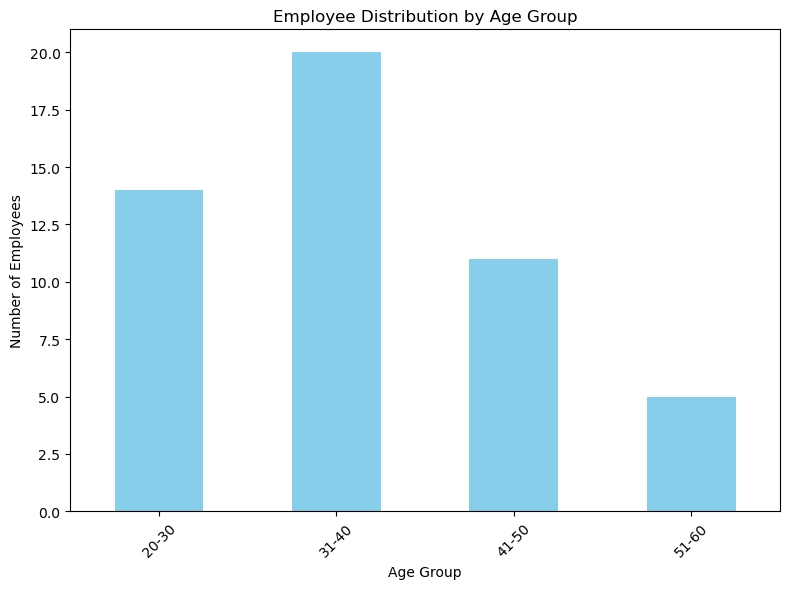

In [155]:
#Employees vs Age group bar graph

import pandas as pd
import matplotlib.pyplot as plt 
cursor = connection.cursor()

sql_select_Query = "SELECT Age FROM Employee"


cursor.execute(sql_select_Query)


ages = [row[0] for row in cursor.fetchall()]

bins = [20, 30, 40, 50, 60]  
labels = ['20-30', '31-40', '41-50', '51-60']  
age_groups = pd.cut(ages, bins=bins, labels=labels, right=False)
age_group_counts = age_groups.value_counts().sort_index()

plt.figure(figsize=(8, 6))
age_group_counts.plot(kind='bar', color='skyblue')
plt.title('Employee Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Working Hours: 39.62 hours


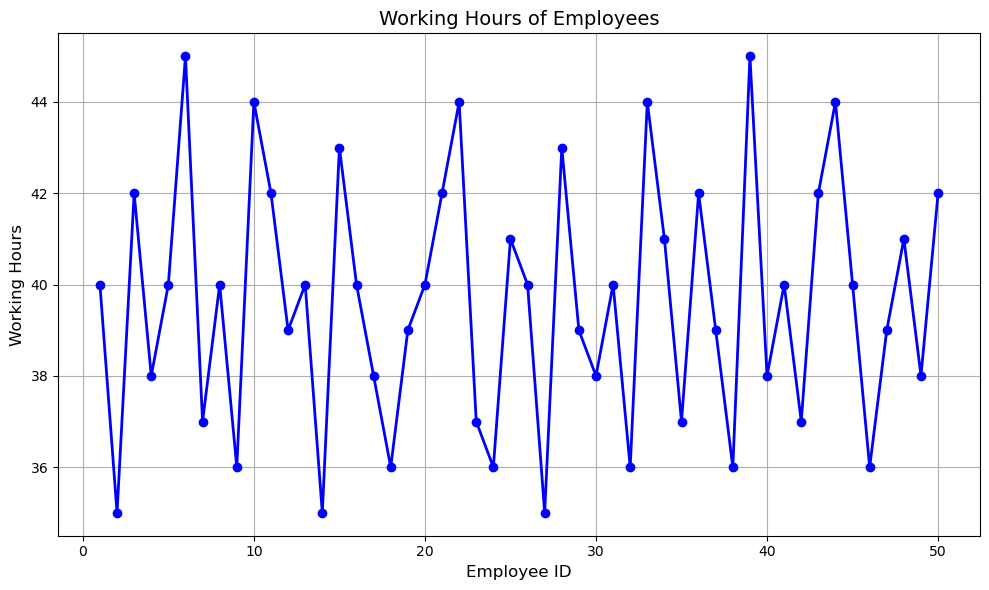

In [157]:
#Employees vs Average working hours of week line graph

cursor = connection.cursor()
sql_select_Query = "SELECT WorkingHours FROM WorkLifeBalance"

cursor.execute(sql_select_Query)


working_hours = [row[0] for row in cursor.fetchall()]

working_hours_series = pd.Series(working_hours)
average_working_hours = working_hours_series.mean()

print(f"Average Working Hours: {average_working_hours:.2f} hours")
working_hours_df = pd.DataFrame({'EmployeeID': range(1, len(working_hours) + 1), 'WorkingHours': working_hours})
plt.figure(figsize=(10, 6))
plt.plot(working_hours_df['EmployeeID'], working_hours_df['WorkingHours'], marker='o', color='b', linestyle='-', linewidth=2)
plt.title('Working Hours of Employees', fontsize=14)
plt.xlabel('Employee ID', fontsize=12)
plt.ylabel('Working Hours', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/z2/5p5_b0_x7t7_2j_5f4nd9nq80000gn/T/ipykernel_96778/2382763742.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_working_hours_by_age_group = df.groupby('AgeGroup')['WorkingHours'].mean()


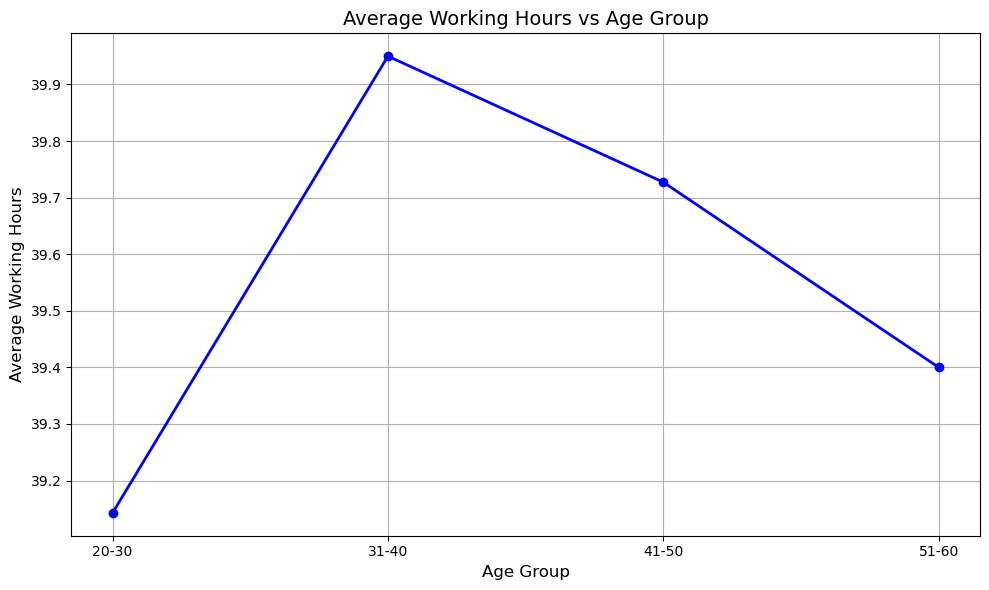

In [159]:
#Avearge working hours vs Age group line graph

cursor = connection.cursor()
sql_select_Query = """
SELECT e.Age, w.WorkingHours
FROM Employee e
JOIN WorkLifeBalance w ON e.EmployeeID = w.EmployeeID
"""
cursor.execute(sql_select_Query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns=['Age', 'WorkingHours'])
bins = [20, 30, 40, 50, 60]
labels = ['20-30', '31-40', '41-50', '51-60']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
avg_working_hours_by_age_group = df.groupby('AgeGroup')['WorkingHours'].mean()


plt.figure(figsize=(10, 6))
plt.plot(avg_working_hours_by_age_group.index, avg_working_hours_by_age_group.values, marker='o', color='b', linestyle='-', linewidth=2)
plt.title('Average Working Hours vs Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Average Working Hours', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/z2/5p5_b0_x7t7_2j_5f4nd9nq80000gn/T/ipykernel_96778/980765597.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_salary_by_age_group = df.groupby('AgeGroup')['Salary'].mean()


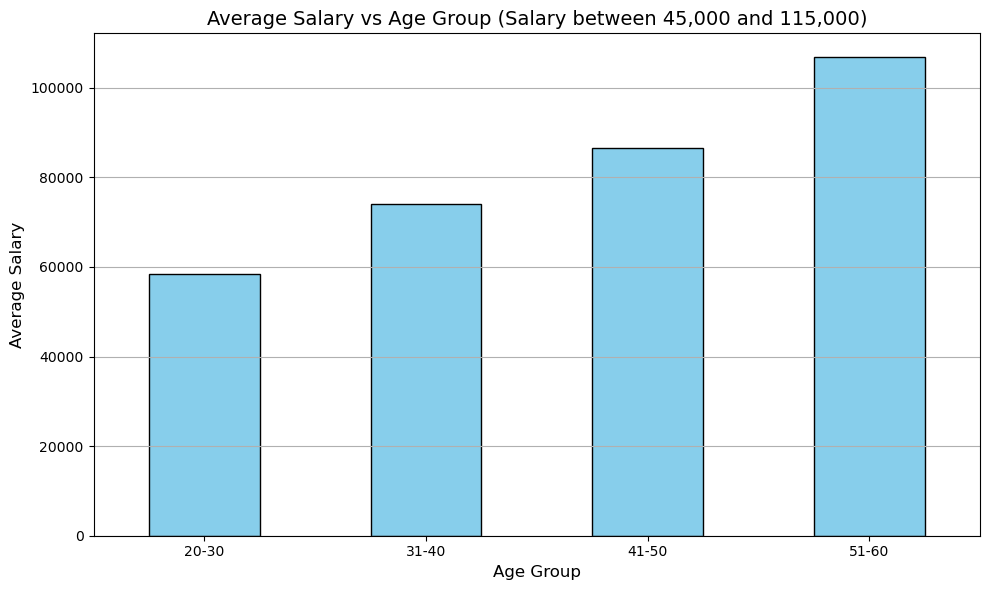

In [161]:
#Average monthly salary vs Age Group bar graph

cursor = connection.cursor()
sql_select_Query = """
SELECT e.Age, e.Salary
FROM Employee e
WHERE e.Salary BETWEEN 45000 AND 115000
"""

cursor.execute(sql_select_Query)
data = cursor.fetchall()

df = pd.DataFrame(data, columns=['Age', 'Salary'])
bins = [20, 30, 40, 50, 60]
labels = ['20-30', '31-40', '41-50', '51-60']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
avg_salary_by_age_group = df.groupby('AgeGroup')['Salary'].mean()
plt.figure(figsize=(10, 6))
avg_salary_by_age_group.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Average Salary vs Age Group (Salary between 45,000 and 115,000)', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Average Salary', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

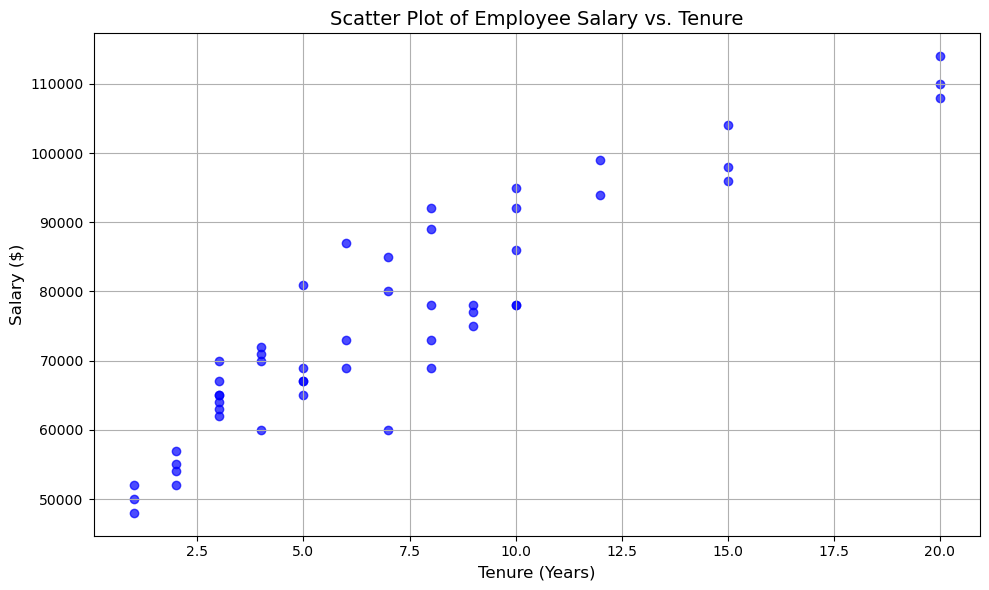

In [163]:
#Emplpoyee salary vs Tenure Scatter plot

query = "SELECT Salary, Tenure FROM Employee WHERE Salary IS NOT NULL AND Tenure IS NOT NULL"
cursor = connection.cursor()
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns=["Salary", "Tenure"])

plt.figure(figsize=(10, 6))
plt.scatter(df["Tenure"], df["Salary"], color='blue', alpha=0.7)
plt.title("Scatter Plot of Employee Salary vs. Tenure", fontsize=14)
plt.xlabel("Tenure (Years)", fontsize=12)
plt.ylabel("Salary ($)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

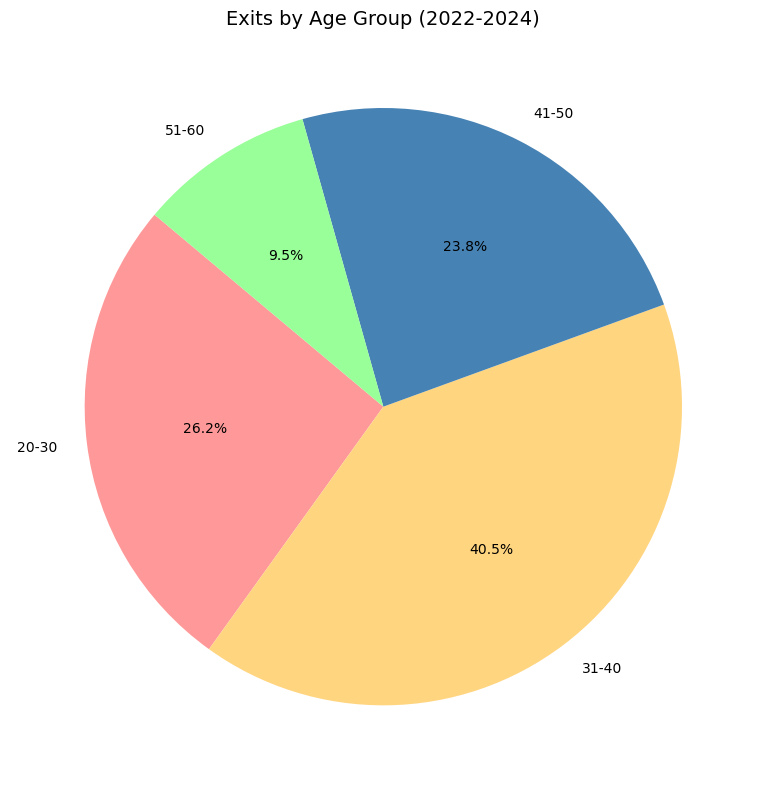

In [165]:
# Employee Attrition percentage between 2022-2024 vs age Group
cursor = connection.cursor()
sql_select_query = """
SELECT e.Age, er.ExitDate
FROM ExitRecord er
JOIN Employee e ON er.EmployeeID = e.EmployeeID
WHERE er.ExitDate BETWEEN '2022-01-01' AND '2024-12-31'
"""
cursor.execute(sql_select_query)
data = cursor.fetchall()
cursor.close()
connection.close()
df = pd.DataFrame(data, columns=['Age', 'ExitDate'])
bins = [20, 30, 40, 50, 60]
labels = ['20-30', '31-40', '41-50', '51-60']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
age_group_exit_counts = df['AgeGroup'].value_counts().sort_index()
custom_colors = ['#FF9999', '#FFD580', '#4682B4', '#99FF99'] 
plt.figure(figsize=(8, 8))
plt.pie(
    age_group_exit_counts, 
    labels=age_group_exit_counts.index, 
    colors=custom_colors, 
    autopct='%1.1f%%', 
    startangle=140
)

plt.title('Exits by Age Group (2022-2024)', fontsize=14)
plt.tight_layout()
plt.show()